In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from collections import defaultdict, deque
from multiprocessing import Manager
from scipy.optimize import linear_sum_assignment
from tqdm.contrib.concurrent import process_map
import networkx as nx
import random
import heapq
import json
from copy import deepcopy
from utils import lineage_name_mapping, load_json, bidict
from zss import simple_distance, Node
from matplotlib import pyplot as plt
from typing import List, Tuple, Dict, Any
from functools import partial
from itertools import combinations
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
import seaborn as sns


from pareto_core import LineageOptimization, LineageTree

In [40]:
lineage_data = load_json('./data/cell_lineage.json')
# lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3.csv", index_col=0)
# lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3_lineage_umap_embedding_5d.csv", index_col=0).T
# lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3_pca_5d.csv", index_col=0)
lineage_exp_df = pd.read_csv("data/protein/aggregated_all/s3_pca_10d.csv", index_col=0)
lineage_exp_df = lineage_exp_df.fillna(0)
# binarize lineage_exp_df, making every value > 3.2 as 1, otherwise 0
# lineage_exp_df = (lineage_exp_df > 3.2).astype(int)
tracking_df_all = pd.read_csv("./data/embryo2/tracks.txt", sep="\t")
tracking_time_cutoff = 247
tracking_scale = 0.1625
tracking_df = tracking_df_all.loc[tracking_df_all["t"] <= tracking_time_cutoff]
untracked_nodes = ["P0", "AB", "P1"]
first_internal_layer = ["ABa", "ABp", "EMS", "P2"]

def depth_cutoff_func(depth):
    if depth <= 9:
        return 1
    else:
        return float('inf')

In [41]:
from collections import defaultdict
terminal_nodes = []
parent_dict = {}
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = lineage_name_mapping(node["did"])
    if len(children) == 0:
        p_lookup_name = lineage_name_mapping(parent['did'])
        parent_dict[lookup_name] = p_lookup_name
        terminal_nodes.append(lookup_name)
        terminal_parents_dict[p_lookup_name].append(lookup_name)
        terminal_ancestry[lookup_name] = ancestors
    else:
        if parent is not None:
            p_lookup_name = lineage_name_mapping(parent['did'])
            parent_dict[lookup_name] = p_lookup_name
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)

In [42]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
count = 0
lineage_type_code_dict = defaultdict(str)
type_code_dict = {}
na_lineages = []
for lineage in terminal_nodes:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        # print(f"No cell types found for lineage: {lineage}")
        na_lineages.append(lineage)
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    # remove nan from cur_lineage_types
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()]
    cur_lineage_types = cur_lineage_types.unique()
    if len(cur_lineage_types) == 0:
        # print(f"No cell types found for lineage: {lineage}")
        na_lineages.append(lineage)
        continue
    cur_type = cur_lineage_types[0]
    if cur_type not in type_code_dict:
        # type_code_dict[cur_type] = chr(97 + len(type_code_dict))  # start from 'a'
        type_code_dict[cur_type] = len(type_code_dict)
    lineage_type_code_dict[lineage] = type_code_dict[cur_type]
# dead/NA type
na_type_code = len(type_code_dict)
type_code_dict["dead/NA"] = na_type_code # unknown/dead type
for lineage in na_lineages:
    lineage_type_code_dict[lineage] = na_type_code

In [43]:
complexity_code_dict = {}
cell_div_count = 0
parent_code_mapping = {}
for node in terminal_nodes:
    complexity_code_dict[node] = lineage_type_code_dict[node]
bfs_queue = deque(terminal_nodes)
while bfs_queue:
    cur_node = bfs_queue.popleft()
    cur_parent = parent_dict.get(cur_node, None)
    cur_node_code = complexity_code_dict.get(cur_node, None)
    if cur_node_code is None:
        print(f"Type code not found for node: {cur_node}")
        continue
    if cur_parent is None:
        print(f"Parent not found for node: {cur_node}")
        continue
    if cur_parent not in complexity_code_dict:
        complexity_code_dict[cur_parent] = cur_node_code
        bfs_queue.append(cur_parent)
    else:
        cur_parent_code = complexity_code_dict[cur_parent]
        if cur_parent_code > cur_node_code:
            parent_code_tuple = (cur_parent_code, cur_node_code)
        else:
            parent_code_tuple = (cur_node_code, cur_parent_code)
        if parent_code_tuple not in parent_code_mapping:
            parent_code_mapping[parent_code_tuple] = len(parent_code_mapping)+len(type_code_dict)
        complexity_code_dict[cur_parent] = parent_code_mapping[parent_code_tuple]
        cell_div_count += 1

    

Parent not found for node: P0


In [44]:
cell_names = tracking_df["name"].unique()
lineage_xyz_df = pd.DataFrame(columns=["x", "y", "z"])
lineage_name_to_last_tracking_time = {}
for name in cell_names:
    time_points = tracking_df.loc[tracking_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == tracking_time_cutoff:
        continue
    lineage_tracks = tracking_df.loc[tracking_df['name'] == name]
    last_xyz_coordinates = lineage_tracks[["x", "y", "z"]].values[-1]
    last_tracking_time = lineage_tracks["t"].values[-1]
    lineage_name_to_last_tracking_time[name] = int(last_tracking_time)
    # appending last_xyz_coordinates to lineage_xyz_df as a new row with cell name as index
    lineage_xyz_df.loc[name] = last_xyz_coordinates * tracking_scale

lineage: tracking_time -> video_time -> wormweb_time

ABp: 7 -> 27 -> 34

ABa: 8 -> 28 -> 35?

P2: 11 -> 31 -> 38

EMS: 14 -> 34 -> 41

AB: -11? -> ? -> 16

P1: -10? -> ? -> 17

P0: -28? -> ? -> -1

In [45]:
# manual estimates based on video and wormweb data for untracked nodes
lineage_name_to_last_tracking_time["AB"] = -11
lineage_name_to_last_tracking_time["P1"] = -10
lineage_name_to_last_tracking_time["P0"] = -28

In [46]:
common_lineages = lineage_xyz_df.index.intersection(lineage_exp_df.index)
for name in untracked_nodes:
    lineage_xyz_df.loc[name] = np.repeat(np.nan, 3)
    lineage_exp_df.loc[name] = np.repeat(np.nan, lineage_exp_df.shape[1])
common_lineages = untracked_nodes + common_lineages.tolist()
lineage_id_to_last_tracking_time = [-1] * len(common_lineages)
for idx, name in enumerate(common_lineages):
    lineage_id_to_last_tracking_time[idx] = lineage_name_to_last_tracking_time.get(name, -1)
    if lineage_name_to_last_tracking_time.get(name, -1) == -1:
        print(f"Warning: No last tracking time for lineage {name}")

In [47]:
# pruning common lineages to include those only leads to terminal nodes
pruned_common_lineages = set()
bfs_queue = deque(terminal_nodes)
while bfs_queue:
    cur_node = bfs_queue.popleft()
    if cur_node in common_lineages:
        pruned_common_lineages.add(cur_node)
        if cur_node in parent_dict:
            bfs_queue.append(parent_dict[cur_node])

In [48]:
# using pruned common lineages, comment out to use all common lineages
new_common_lineages = []
for lineage in common_lineages:
    if lineage in pruned_common_lineages:
        new_common_lineages.append(lineage)
old_commmon_lineages = common_lineages.copy()
common_lineages = new_common_lineages

In [49]:
common_lineages = old_commmon_lineages

In [50]:
lineage_tree = LineageTree()
# add first three nodes: ["AB", "P0", "P1"]
missing_first_nodes = ["P0", "AB", "P1"]
lineage_tree.add_node(0, -1)
lineage_tree.root = 0
lineage_tree.add_node(1, 0)
lineage_tree.add_node(2, 0)
bfs_queue = deque()
bfs_queue.append((lineage_data, -1))
while bfs_queue:
    node, parent_idx = bfs_queue.popleft()
    curr_name = lineage_name_mapping(node['did'])
    if curr_name not in common_lineages:
        continue
    curr_idx = common_lineages.index(curr_name)
    if curr_idx >= 3:
        parent_idx = lineage_tree.reverse_lineage_id_mapping[parent_idx]
        lineage_tree.add_node(curr_idx, parent_idx)
    children = node.get('children', [])
    for child_node in children:
        bfs_queue.append((child_node, curr_idx))
lineage_tree.record_last_tracked_time(lineage_id_to_last_tracking_time)

print("first layer of tracked nodes:", lineage_tree.children_list[1]+lineage_tree.children_list[2])

first layer of tracked nodes: [3, 4, 5, 6]


In [51]:
lineage_xyz_mat = lineage_xyz_df.loc[common_lineages].values
lineage_exp_mat = lineage_exp_df.loc[common_lineages].values

In [52]:
first_layer = [(3,2), (4,2), (5,2), (6,2)]
# first_layer = [(5,2)]

opt = LineageOptimization(
    lineage_xyz_mat, 
    lineage_exp_mat,
    lineage_tree,
    first_internal_layer=first_layer,
    lineage_names=common_lineages, 
    lineage_type_code_dict=complexity_code_dict,
    exp_norm=2)

4462.569048220268 93620.46185550421 1002
Complexity Score of the original lineage tree: 0.38492063492063494


In [29]:
res = opt.phylogenetic_sampling()
print(res[1])

4395.348868524849


In [ ]:
random_res_by_layer = opt.random_assignment_by_layer_runner()

Computing random assignment by layer costs...:   0%|          | 0/1000000 [00:00<?, ?it/s]

In [31]:
random_xyz_by_layer = [cost[0] for cost in random_res_by_layer]
random_exp_by_layer = [cost[1] for cost in random_res_by_layer]

In [16]:
pareto_df_terminal_only_kd_internal = pd.read_csv('output/internal_opt/embryo2/s3_280_l2/pareto_terminal_only_kd_internal.tsv', sep='\t')
pareto_xyz_cost_list_terminal_only_kd_internal = pareto_df_terminal_only_kd_internal['xyz_cost'].tolist()
pareto_exp_cost_list_terminal_only_kd_internal = pareto_df_terminal_only_kd_internal['exp_cost'].tolist()
pareto_internal_selection_count_list_terminal_only_kd_internal = [eval(s) for s in pareto_df_terminal_only_kd_internal['internal_selection_count'].tolist()]

In [17]:
internal_lineage_ids = [opt.lineage_tree.lineage_id_mapping[tree_id] for tree_id in opt.internal_tree_ids]
internal_lineage_names = [opt.lineage_names[i] for i in internal_lineage_ids]

In [ ]:
random_res = opt.random_rebuild_runner(iterations=1000000)
random_xyz_costs = [cost[0] for cost in random_res]
random_exp_costs = [cost[1] for cost in random_res]
print(np.mean(random_xyz_costs), np.mean(random_exp_costs))
print(np.std(random_xyz_costs), np.std(random_exp_costs))
print((np.mean(random_xyz_costs) - opt.lineage_xyz_cost) / np.std(random_xyz_costs))
print((np.mean(random_exp_costs) - opt.lineage_exp_cost) / np.std(random_exp_costs))

In [38]:
random_assign_res = opt.random_assignment_runner(iterations=1000000)
random_xyz_costs = [cost[0] for cost in random_assign_res]
random_exp_costs = [cost[1] for cost in random_assign_res]
print(np.mean(random_xyz_costs), np.mean(random_exp_costs))
print(np.std(random_xyz_costs), np.std(random_exp_costs))
print((np.mean(random_xyz_costs) - opt.lineage_xyz_cost) / np.std(random_xyz_costs))
print((np.mean(random_exp_costs) - opt.lineage_exp_cost) / np.std(random_exp_costs))

Computing random assignment costs...:   0%|          | 0/1000000 [00:00<?, ?it/s]

17830.25324601653 186938.81473784114
206.03255623497472 1228.537170811214
64.88141700552785
59.569570611709565


In [ ]:
pareto_list_by_layer = opt.bottom_up_by_layer_runner()
pareto_list_top_down_rebuild = opt.top_down_rebuild_runner()
pareto_mst_list = opt.mst_rebuild_runner()
pareto_list_top_down_rebuild_depth_cutoff = opt.top_down_rebuild_runner(depth_weight_type=depth_cutoff_func)

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

In [ ]:
pareto_list_paired_bottom_up_rebuild = opt.paired_bottom_up_rebuild_runner()

Computing pareto costs 1/4:   0%|          | 0/250 [00:00<?, ?it/s]

Computing pareto costs 2/4:   0%|          | 0/250 [00:00<?, ?it/s]

Computing pareto costs 3/4:   0%|          | 0/250 [00:00<?, ?it/s]

Computing pareto costs 4/4:   0%|          | 0/251 [00:00<?, ?it/s]

In [ ]:
pareto_list_terminal_only_kd_internal = opt.terminal_only_rebuild_runner(use_kd_tree=True)


Computing pareto costs 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Computing pareto costs 2/2:   0%|          | 0/501 [00:00<?, ?it/s]

In [38]:
# save pareto_list_terminal_only_kd_internal as a pandas dataframe
pareto_df_terminal_only_kd_internal = pd.DataFrame(pareto_list_terminal_only_kd_internal, columns=['xyz_cost', 'exp_cost', 'internal_selection_count', 'complexity_score', 'min_consines', 'mean_consines'])
pareto_df_terminal_only_kd_internal.to_csv('output/internal_opt/embryo2/10_pca_247_l2/pareto_terminal_only_kd_internal.tsv', index=False, sep='\t')

In [22]:
results_df = pd.read_csv('output/internal_opt/embryo2/s3_280_l2/pareto_comparison.csv')
pareto_xyz_cost_list_by_layer = results_df["Bottom-up By Layer XYZ Cost"].tolist()
pareto_exp_cost_list_by_layer = results_df["Bottom-up By Layer Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild = results_df["Top-Down Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild = results_df["Top-Down Rebuild Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) Exp Cost"].tolist()
pareto_xyz_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild Exp Cost"].tolist()    
pareto_xyz_cost_list_mst = results_df["MST Based Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_mst = results_df["MST Based Rebuild Exp Cost"].tolist()

In [37]:
min(pareto_xyz_cost_list_by_layer)

np.float64(3769.5669143431005)

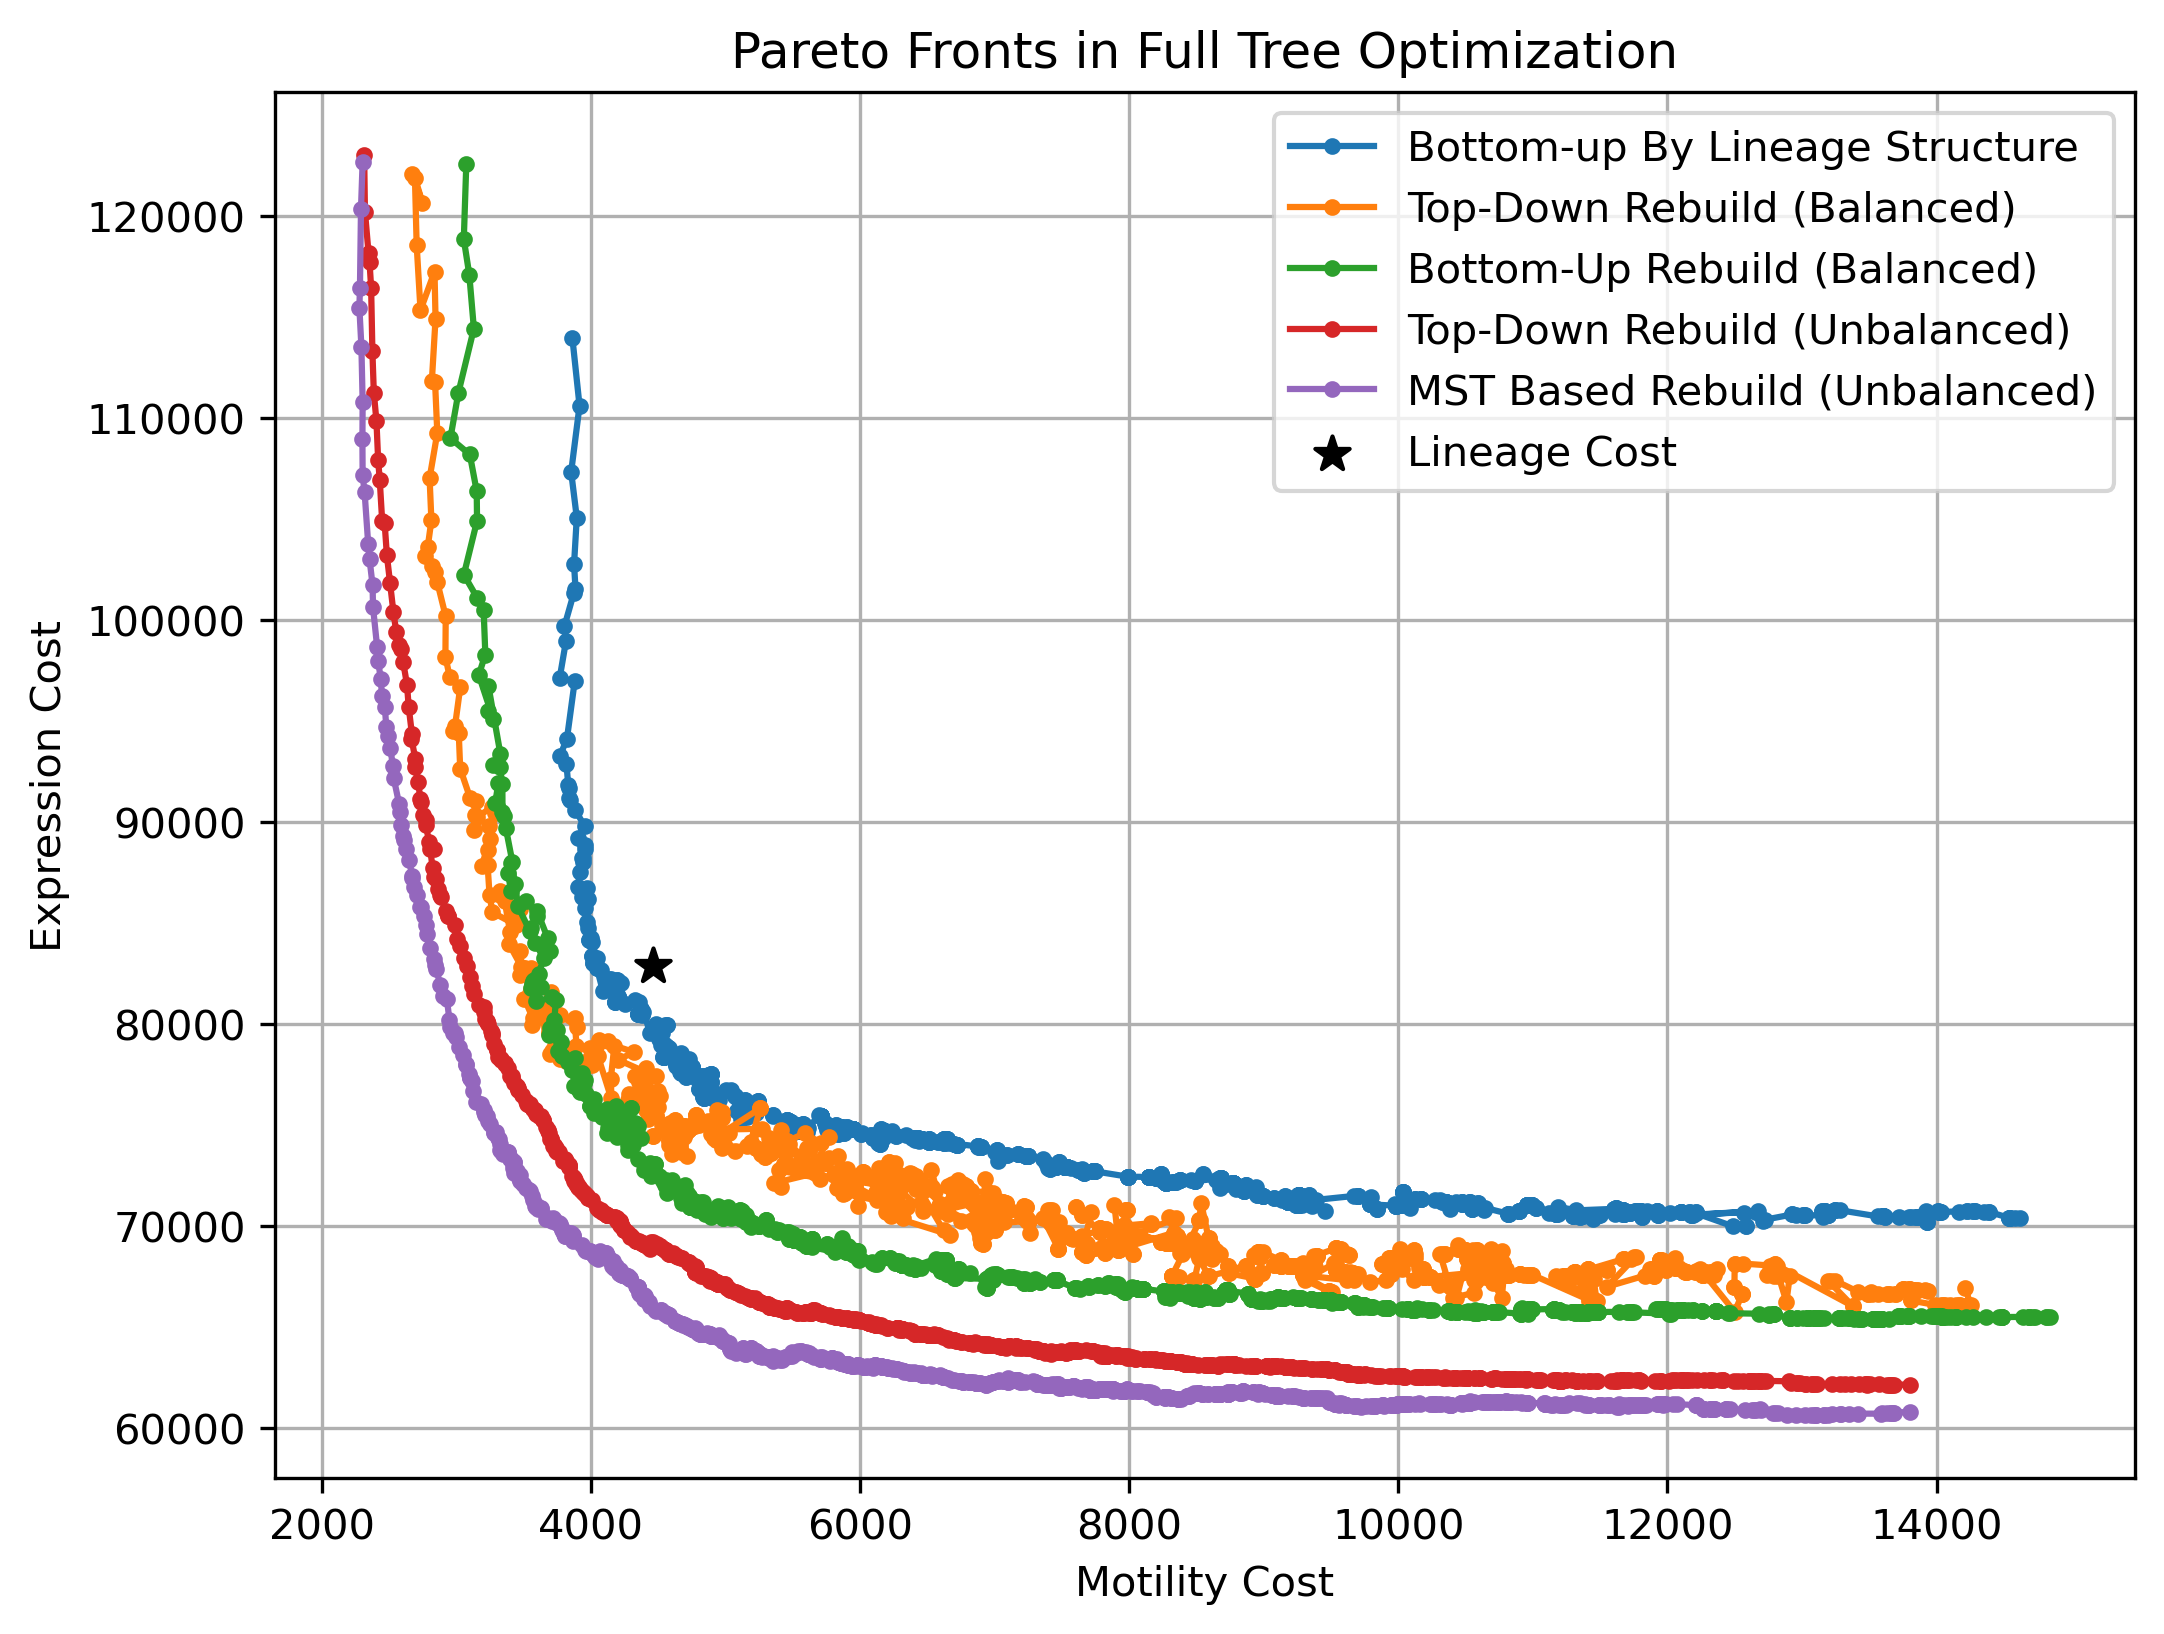

In [18]:
pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_top_down_rebuild = [cost[0] for cost in pareto_list_top_down_rebuild]
pareto_exp_cost_list_top_down_rebuild = [cost[1] for cost in pareto_list_top_down_rebuild]
pareto_xyz_cost_list_mst = [cost[0] for cost in pareto_mst_list]
pareto_exp_cost_list_mst = [cost[1] for cost in pareto_mst_list]
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = [cost[0] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = [cost[1] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_xyz_cost_list_paired_bottom_up_rebuild = [cost[0] for cost in pareto_list_paired_bottom_up_rebuild]
pareto_exp_cost_list_paired_bottom_up_rebuild = [cost[1] for cost in pareto_list_paired_bottom_up_rebuild]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-',  markersize=3, label='Bottom-up By Lineage Structure')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff, pareto_exp_cost_list_top_down_rebuild_depth_cutoff, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (Unbalanced)')
plt.plot(pareto_xyz_cost_list_mst, pareto_exp_cost_list_mst, marker='o', linestyle='-',  markersize=3, label='MST Based Rebuild (Unbalanced)')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='black', marker='*', label='Lineage Cost', zorder=99, s=75)
plt.title(f'Pareto Fronts in Full Tree Optimization')
plt.grid(True)
plt.legend()
plt.show()

/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


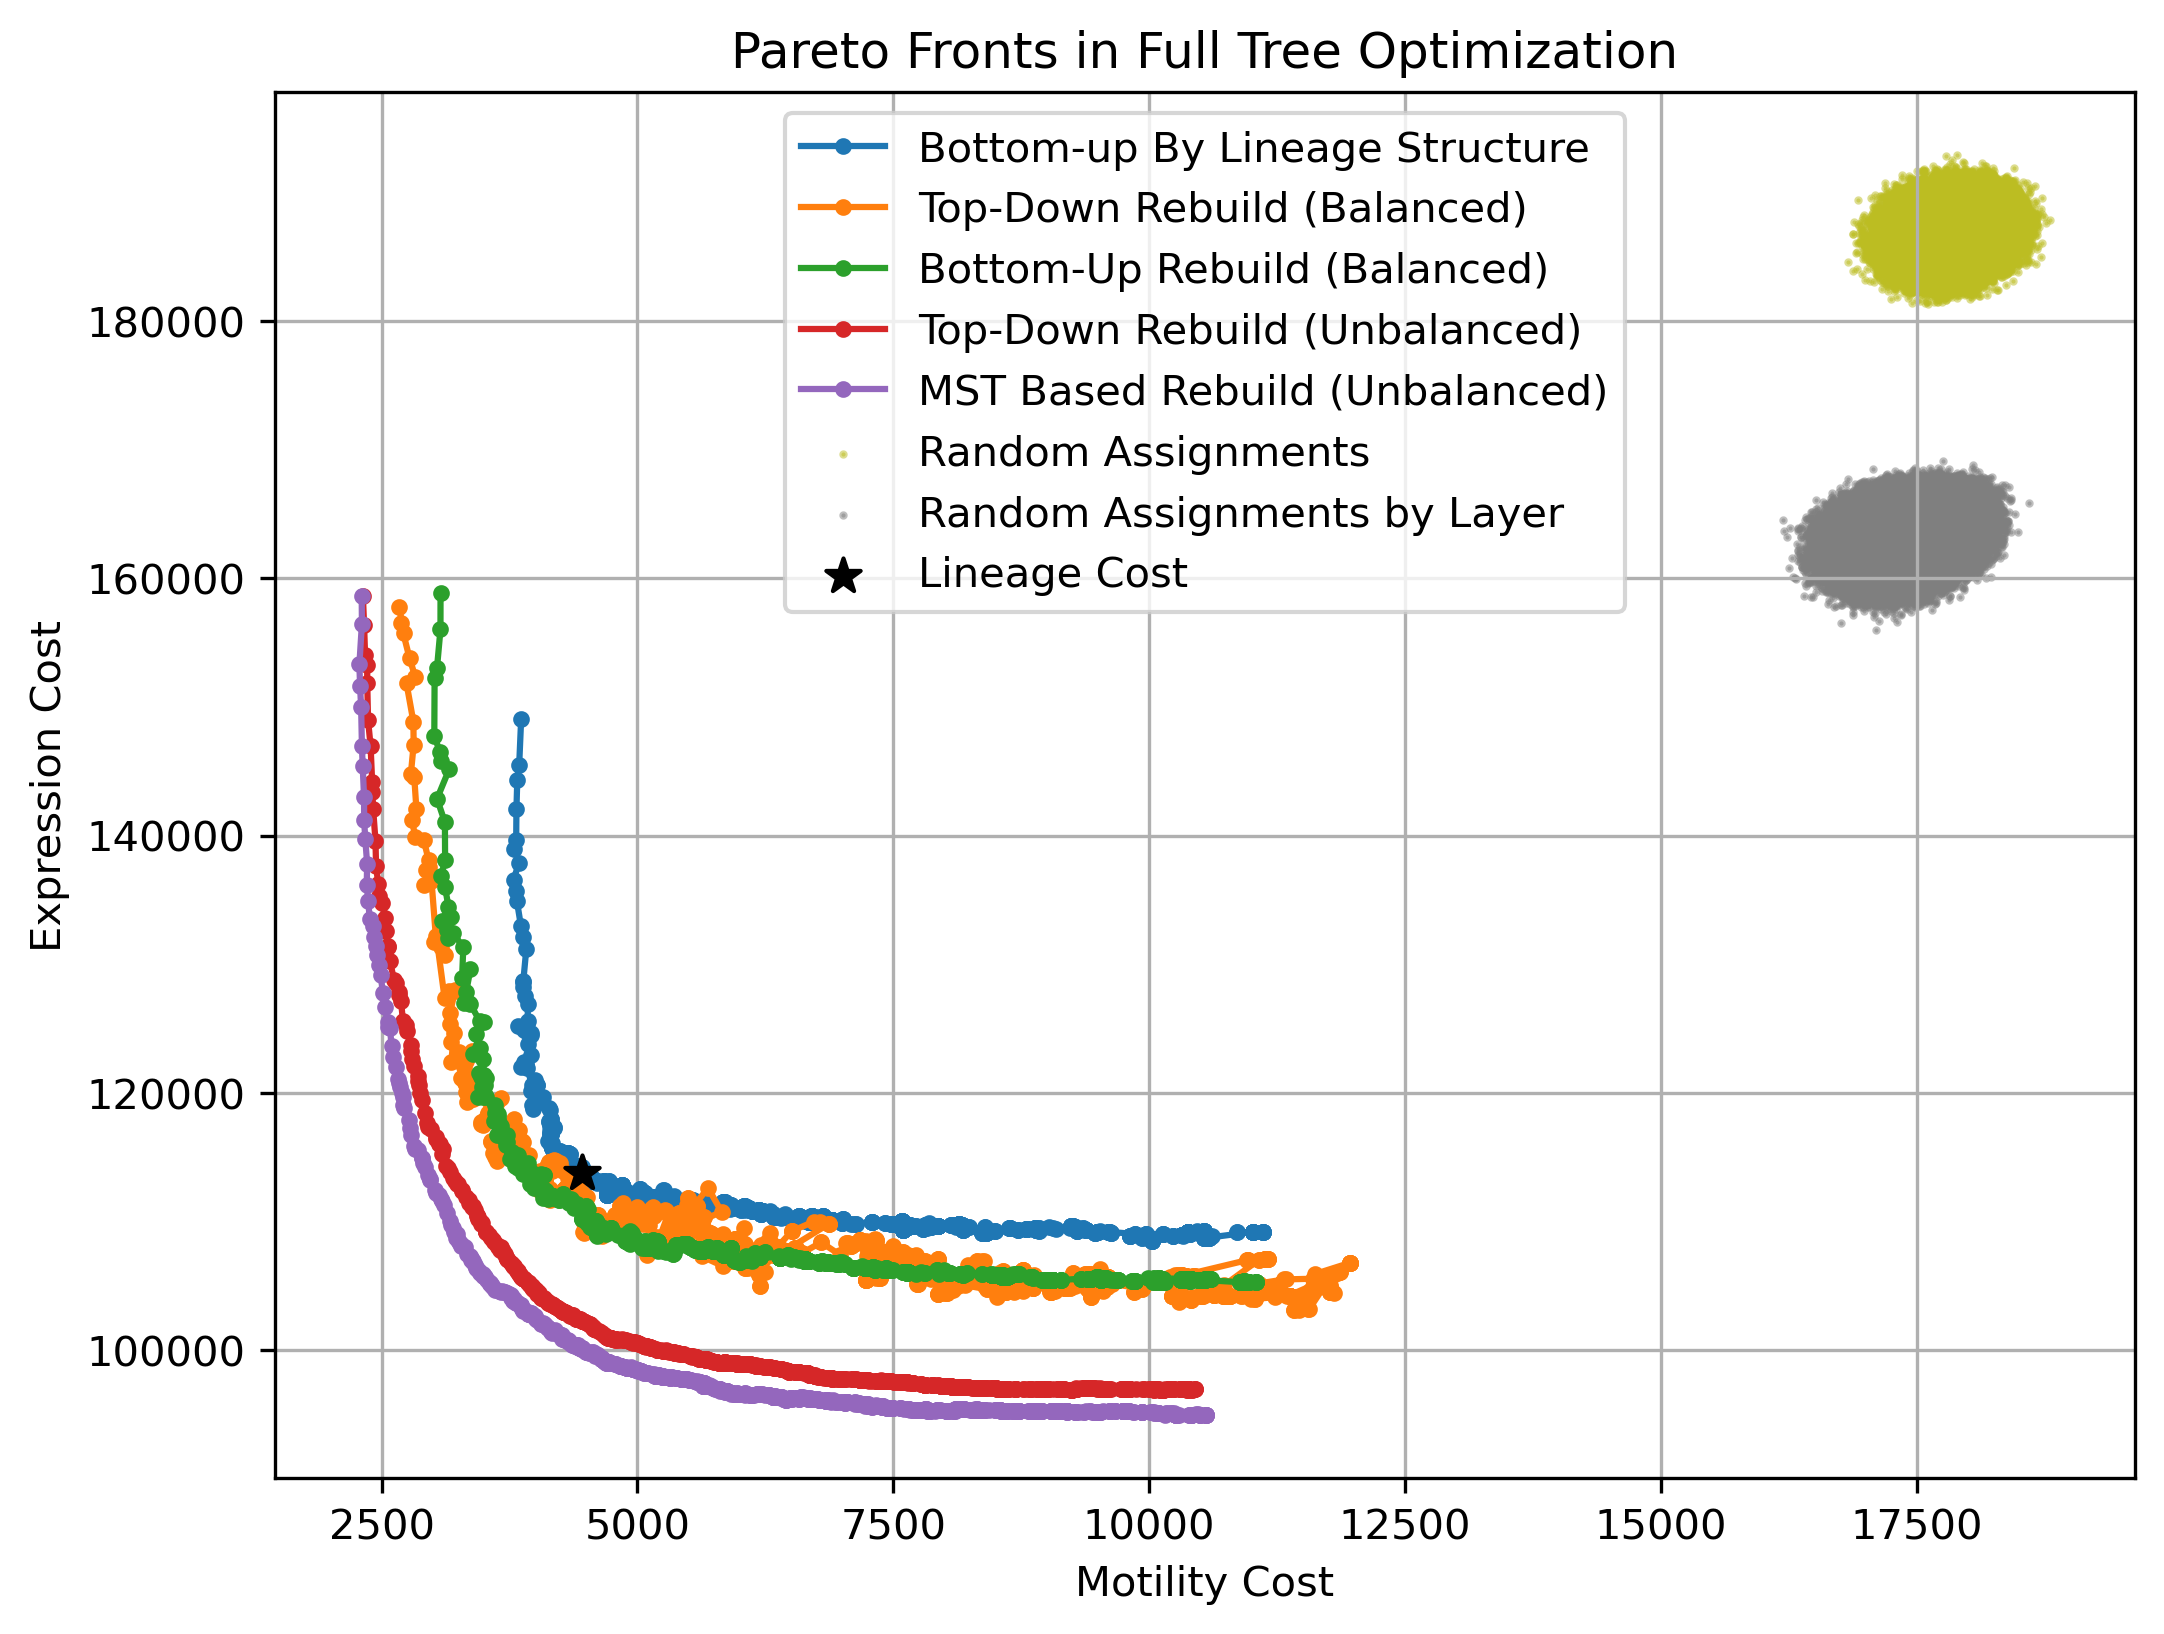

In [40]:
random_assign_xyz_costs = [cost[0] for cost in random_assign_res]
random_assign_exp_costs = [cost[1] for cost in random_assign_res]
# random_rebuild_xyz_costs = [cost[0] for cost in random_res]
# random_rebuild_exp_costs = [cost[1] for cost in random_res]
colors = sns.color_palette(n_colors=10)
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-',  markersize=3, label='Bottom-up By Lineage Structure')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff, pareto_exp_cost_list_top_down_rebuild_depth_cutoff, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild (Balanced)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (Unbalanced)')
plt.plot(pareto_xyz_cost_list_mst, pareto_exp_cost_list_mst, marker='o', linestyle='-',  markersize=3, label='MST Based Rebuild (Unbalanced)')
plt.scatter(random_assign_xyz_costs, random_assign_exp_costs, alpha=0.5, s=1, color=colors[8], label='Random Assignments')
plt.scatter(random_xyz_by_layer, random_exp_by_layer, alpha=0.5, s=1, color=colors[7], label='Random Assignments by Layer')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='black', marker='*', label='Lineage Cost', zorder=99, s=75)
plt.title(f'Pareto Fronts in Full Tree Optimization')
plt.grid(True)
plt.legend()
plt.show()

In [39]:
results_df = pd.DataFrame({
    'Bottom-up By Layer XYZ Cost': pareto_xyz_cost_list_by_layer,
    'Bottom-up By Layer Exp Cost': pareto_exp_cost_list_by_layer,
    'Top-Down Rebuild XYZ Cost': pareto_xyz_cost_list_top_down_rebuild,
    'Top-Down Rebuild Exp Cost': pareto_exp_cost_list_top_down_rebuild,
    'Paired Bottom-Up Rebuild XYZ Cost': pareto_xyz_cost_list_paired_bottom_up_rebuild,
    'Paired Bottom-Up Rebuild Exp Cost': pareto_exp_cost_list_paired_bottom_up_rebuild,
    'MST Based Rebuild XYZ Cost': pareto_xyz_cost_list_mst,
    'MST Based Rebuild Exp Cost': pareto_exp_cost_list_mst,
    'Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost': pareto_xyz_cost_list_top_down_rebuild_depth_cutoff,
    'Top-Down Rebuild (Hard Depth Cutoff) Exp Cost': pareto_exp_cost_list_top_down_rebuild_depth_cutoff
})
results_df.to_csv('output/internal_opt/embryo2/10_pca_247_l2/pareto_comparison.csv', index=False)

In [38]:
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = [cost[0] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = [cost[1] for cost in pareto_list_top_down_rebuild_depth_cutoff]
depth_restricted_top_down_rebuild_complexity_scores = [cost[2] for cost in pareto_list_top_down_rebuild_depth_cutoff]

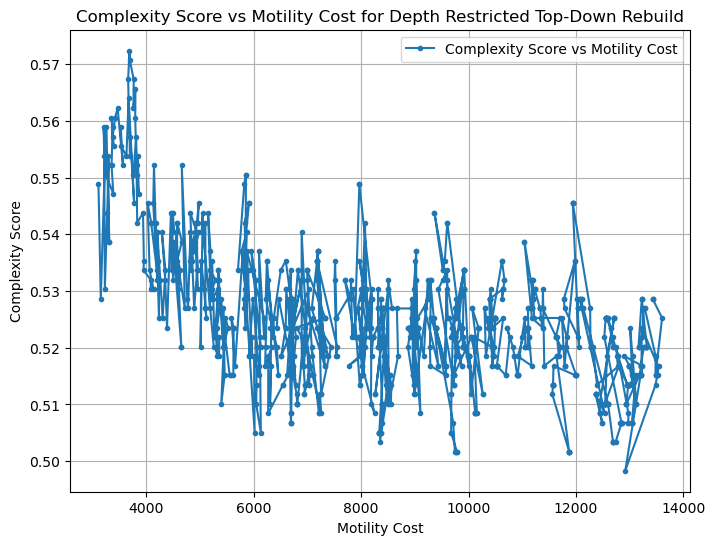

In [39]:
# plot depth_restricted_top_down_rebuild_complexity_scores against pareto_exp_xyz_list_top_down_rebuild_depth_cutoff
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff, depth_restricted_top_down_rebuild_complexity_scores, marker='o', linestyle='-',  markersize=3, label='Complexity Score vs Motility Cost')
plt.xlabel('Motility Cost')
plt.ylabel('Complexity Score')
plt.title(f'Complexity Score vs Motility Cost for Depth Restricted Top-Down Rebuild')
plt.grid(True)
plt.legend()
plt.show()

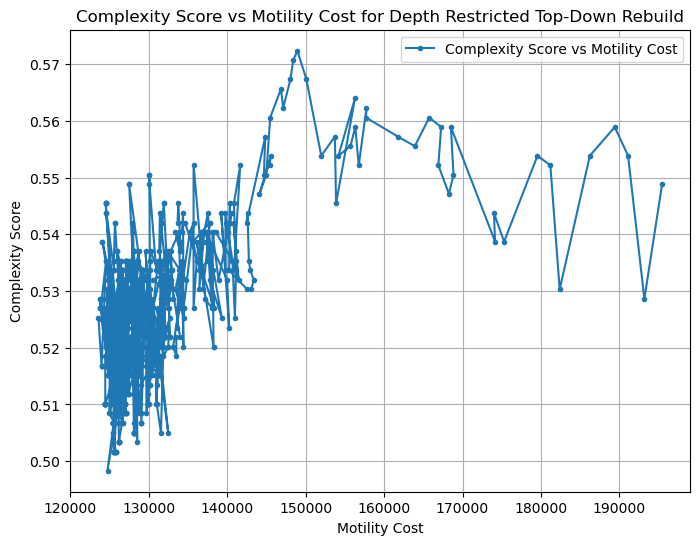

In [40]:
# plot depth_restricted_top_down_rebuild_complexity_scores against pareto_exp_xyz_list_top_down_rebuild_depth_cutoff
plt.figure(figsize=(8, 6))
plt.plot(pareto_exp_cost_list_top_down_rebuild_depth_cutoff, depth_restricted_top_down_rebuild_complexity_scores, marker='o', linestyle='-',  markersize=3, label='Complexity Score vs Motility Cost')
plt.xlabel('Motility Cost')
plt.ylabel('Complexity Score')
plt.title(f'Complexity Score vs Motility Cost for Depth Restricted Top-Down Rebuild')
plt.grid(True)
plt.legend()
plt.show()

In [41]:
from scipy.stats import spearmanr
r, p = spearmanr(depth_restricted_top_down_rebuild_complexity_scores, pareto_exp_cost_list_top_down_rebuild_depth_cutoff)

In [42]:
print(r, p)

0.3401122452863597 1.5830235556618475e-28


In [19]:

terminal_lineage_ids = [opt.lineage_tree.lineage_id_mapping[tree_id] for tree_id in opt.terminal_tree_ids]
internal_lineage_ids = [opt.lineage_tree.lineage_id_mapping[tree_id] for tree_id in opt.internal_tree_ids]
res0 = opt.terminal_only_rebuild(terminal_lineage_ids=terminal_lineage_ids, internal_lineage_ids=internal_lineage_ids, use_kd_tree=True, idx=0)
res1 = opt.terminal_only_rebuild(terminal_lineage_ids=terminal_lineage_ids, internal_lineage_ids=internal_lineage_ids, use_kd_tree=True, idx=1001)

In [20]:
terminal_path_lists = []
for tree_id in opt.terminal_tree_ids:
    cur_id = tree_id
    terminal_path = [opt.lineage_tree.lineage_id_mapping[tree_id]]
    while opt.lineage_tree.parent_list[cur_id] != -1:
        cur_id = opt.lineage_tree.parent_list[cur_id]
        terminal_path.append(opt.lineage_tree.lineage_id_mapping[cur_id])
    terminal_path_lists.append(terminal_path)


min_cosines = []
mean_cosines = []
for path in terminal_path_lists:
    min_cosine = 1.0
    cosine_values = []
    for i in range(1, len(path) -1):
        vec1 = lineage_exp_mat[path[i]] - lineage_exp_mat[path[i -1]]
        vec2 = lineage_exp_mat[path[i +1]] - lineage_exp_mat[path[i]]
        cos_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2) + 1e-10)
        if np.isnan(cos_angle):
            continue
        min_cosine = min(min_cosine, cos_angle)
        cosine_values.append(cos_angle)
    min_cosines.append(min_cosine)
    mean_cosines.append(np.mean(cosine_values[:8]))

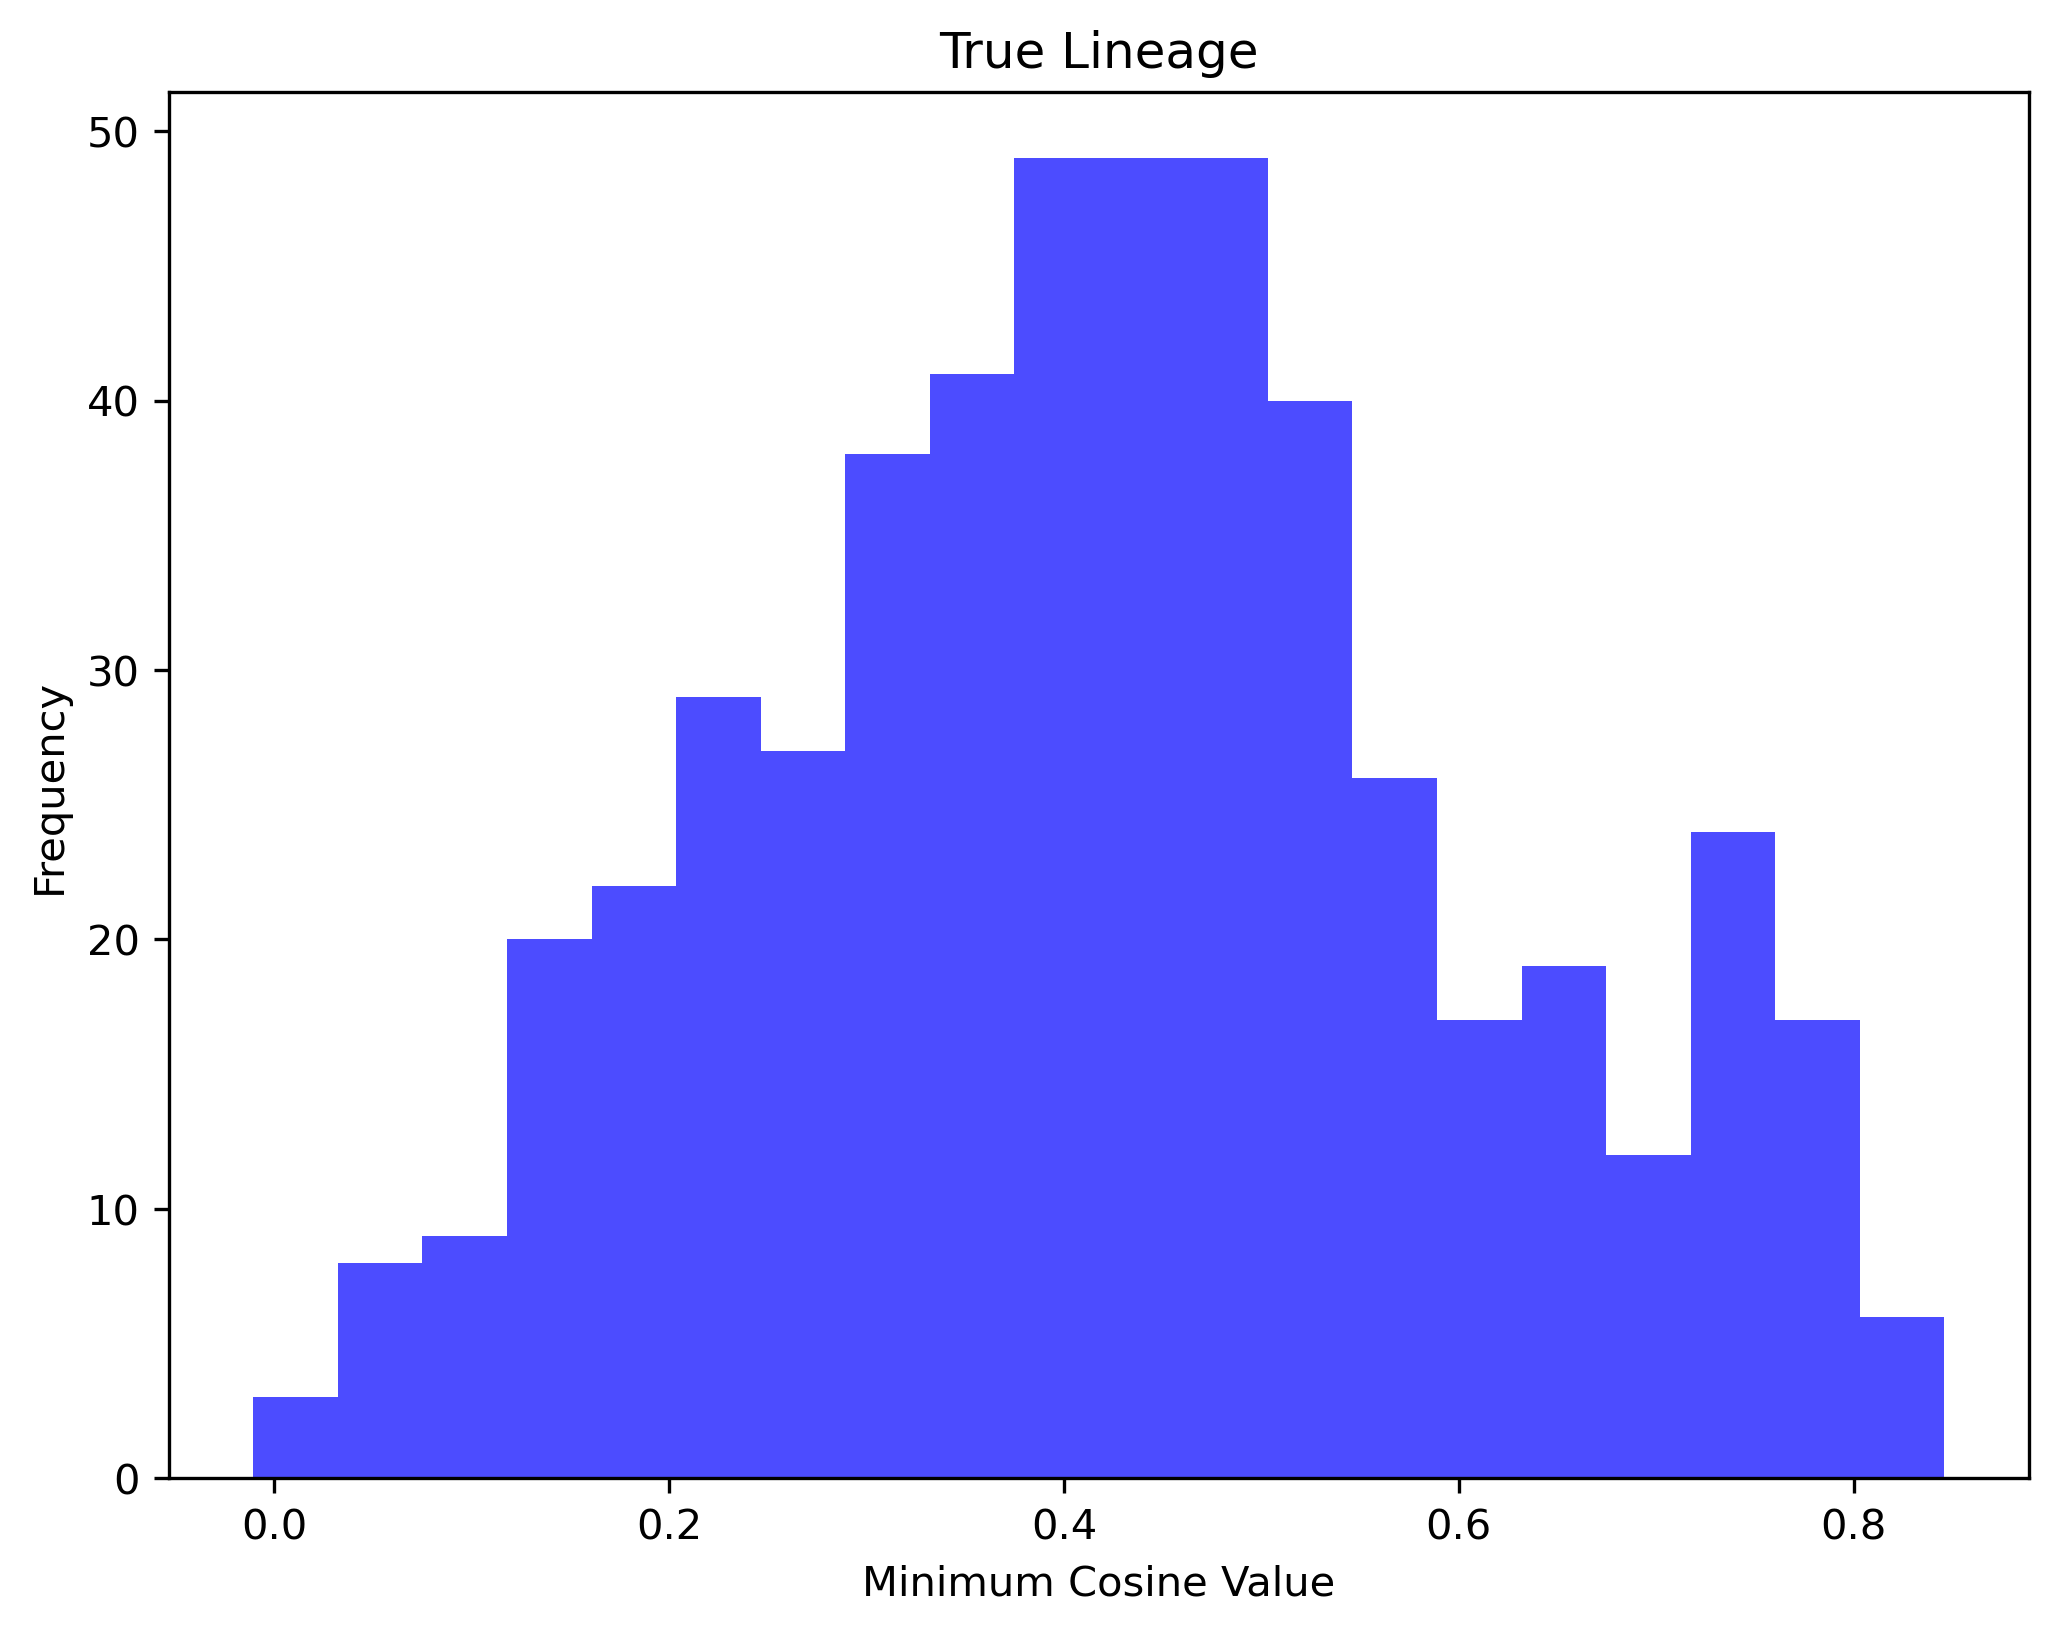

In [21]:
# plot a histogram of mean_cosines
plt.figure(figsize=(8, 6))
plt.hist(mean_cosines, bins=20, color='blue', alpha=0.7)
plt.xlabel('Minimum Cosine Value')
plt.ylabel('Frequency')
plt.title('True Lineage')
plt.show()

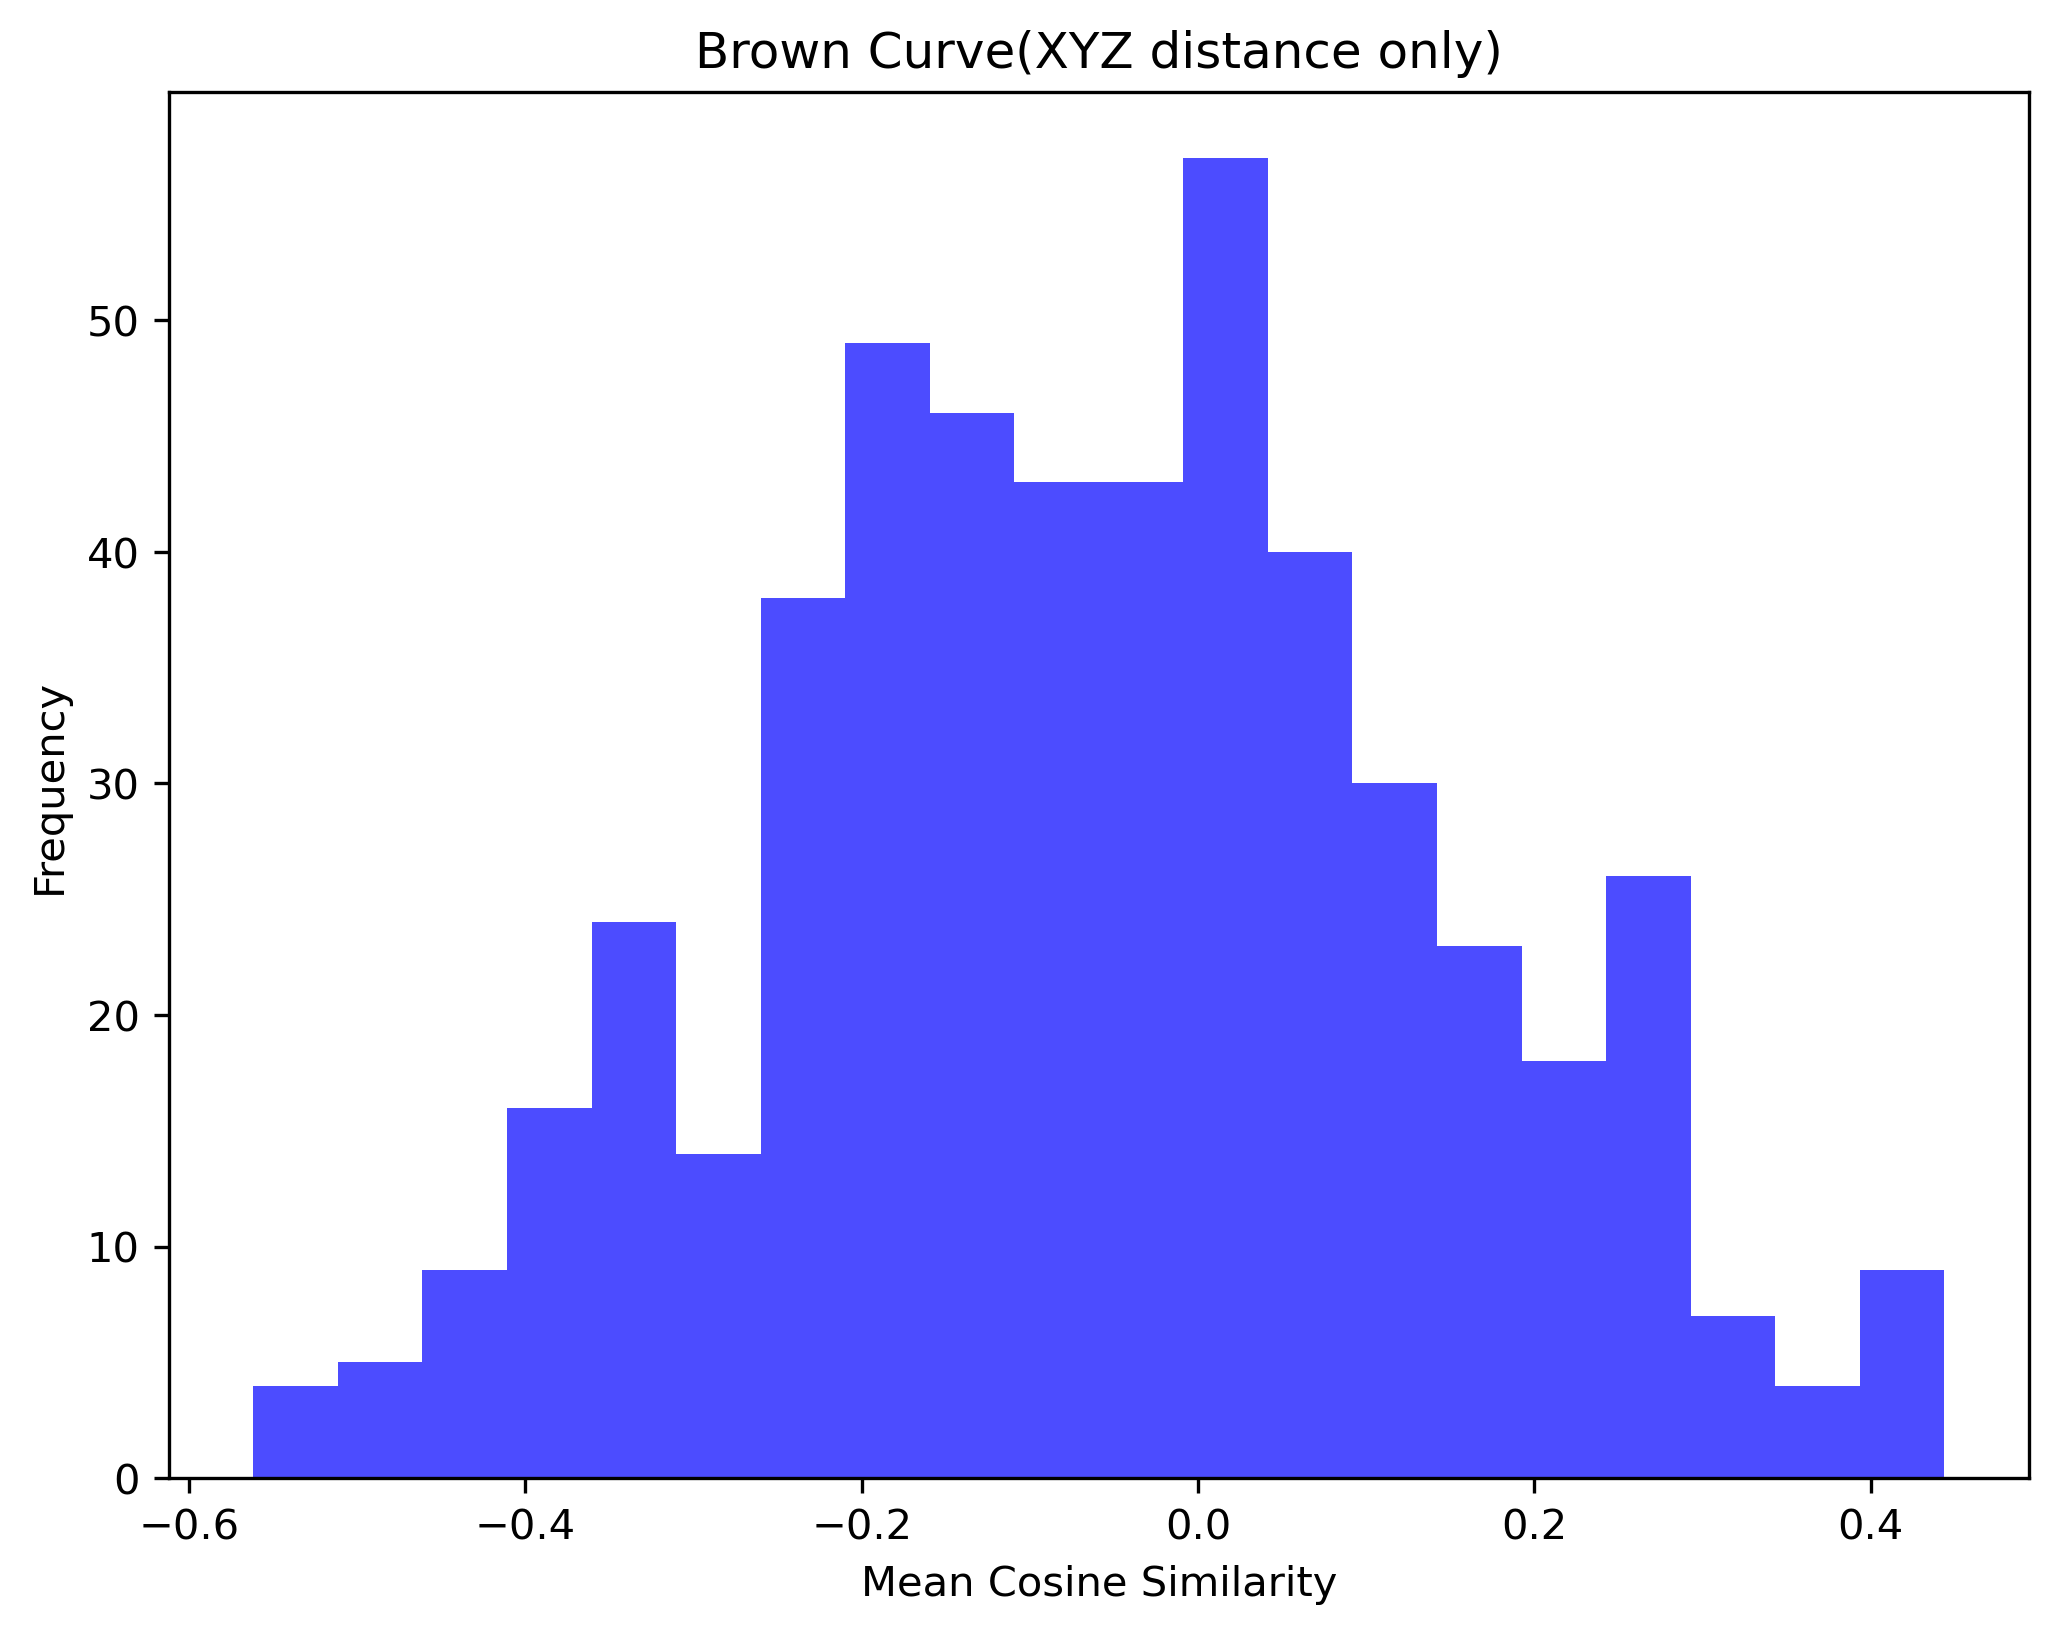

In [22]:

plt.figure(figsize=(8, 6))
plt.hist(res1[5], bins=20, color='blue', alpha=0.7)
plt.xlabel('Mean Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Brown Curve(XYZ distance only)')
plt.show()

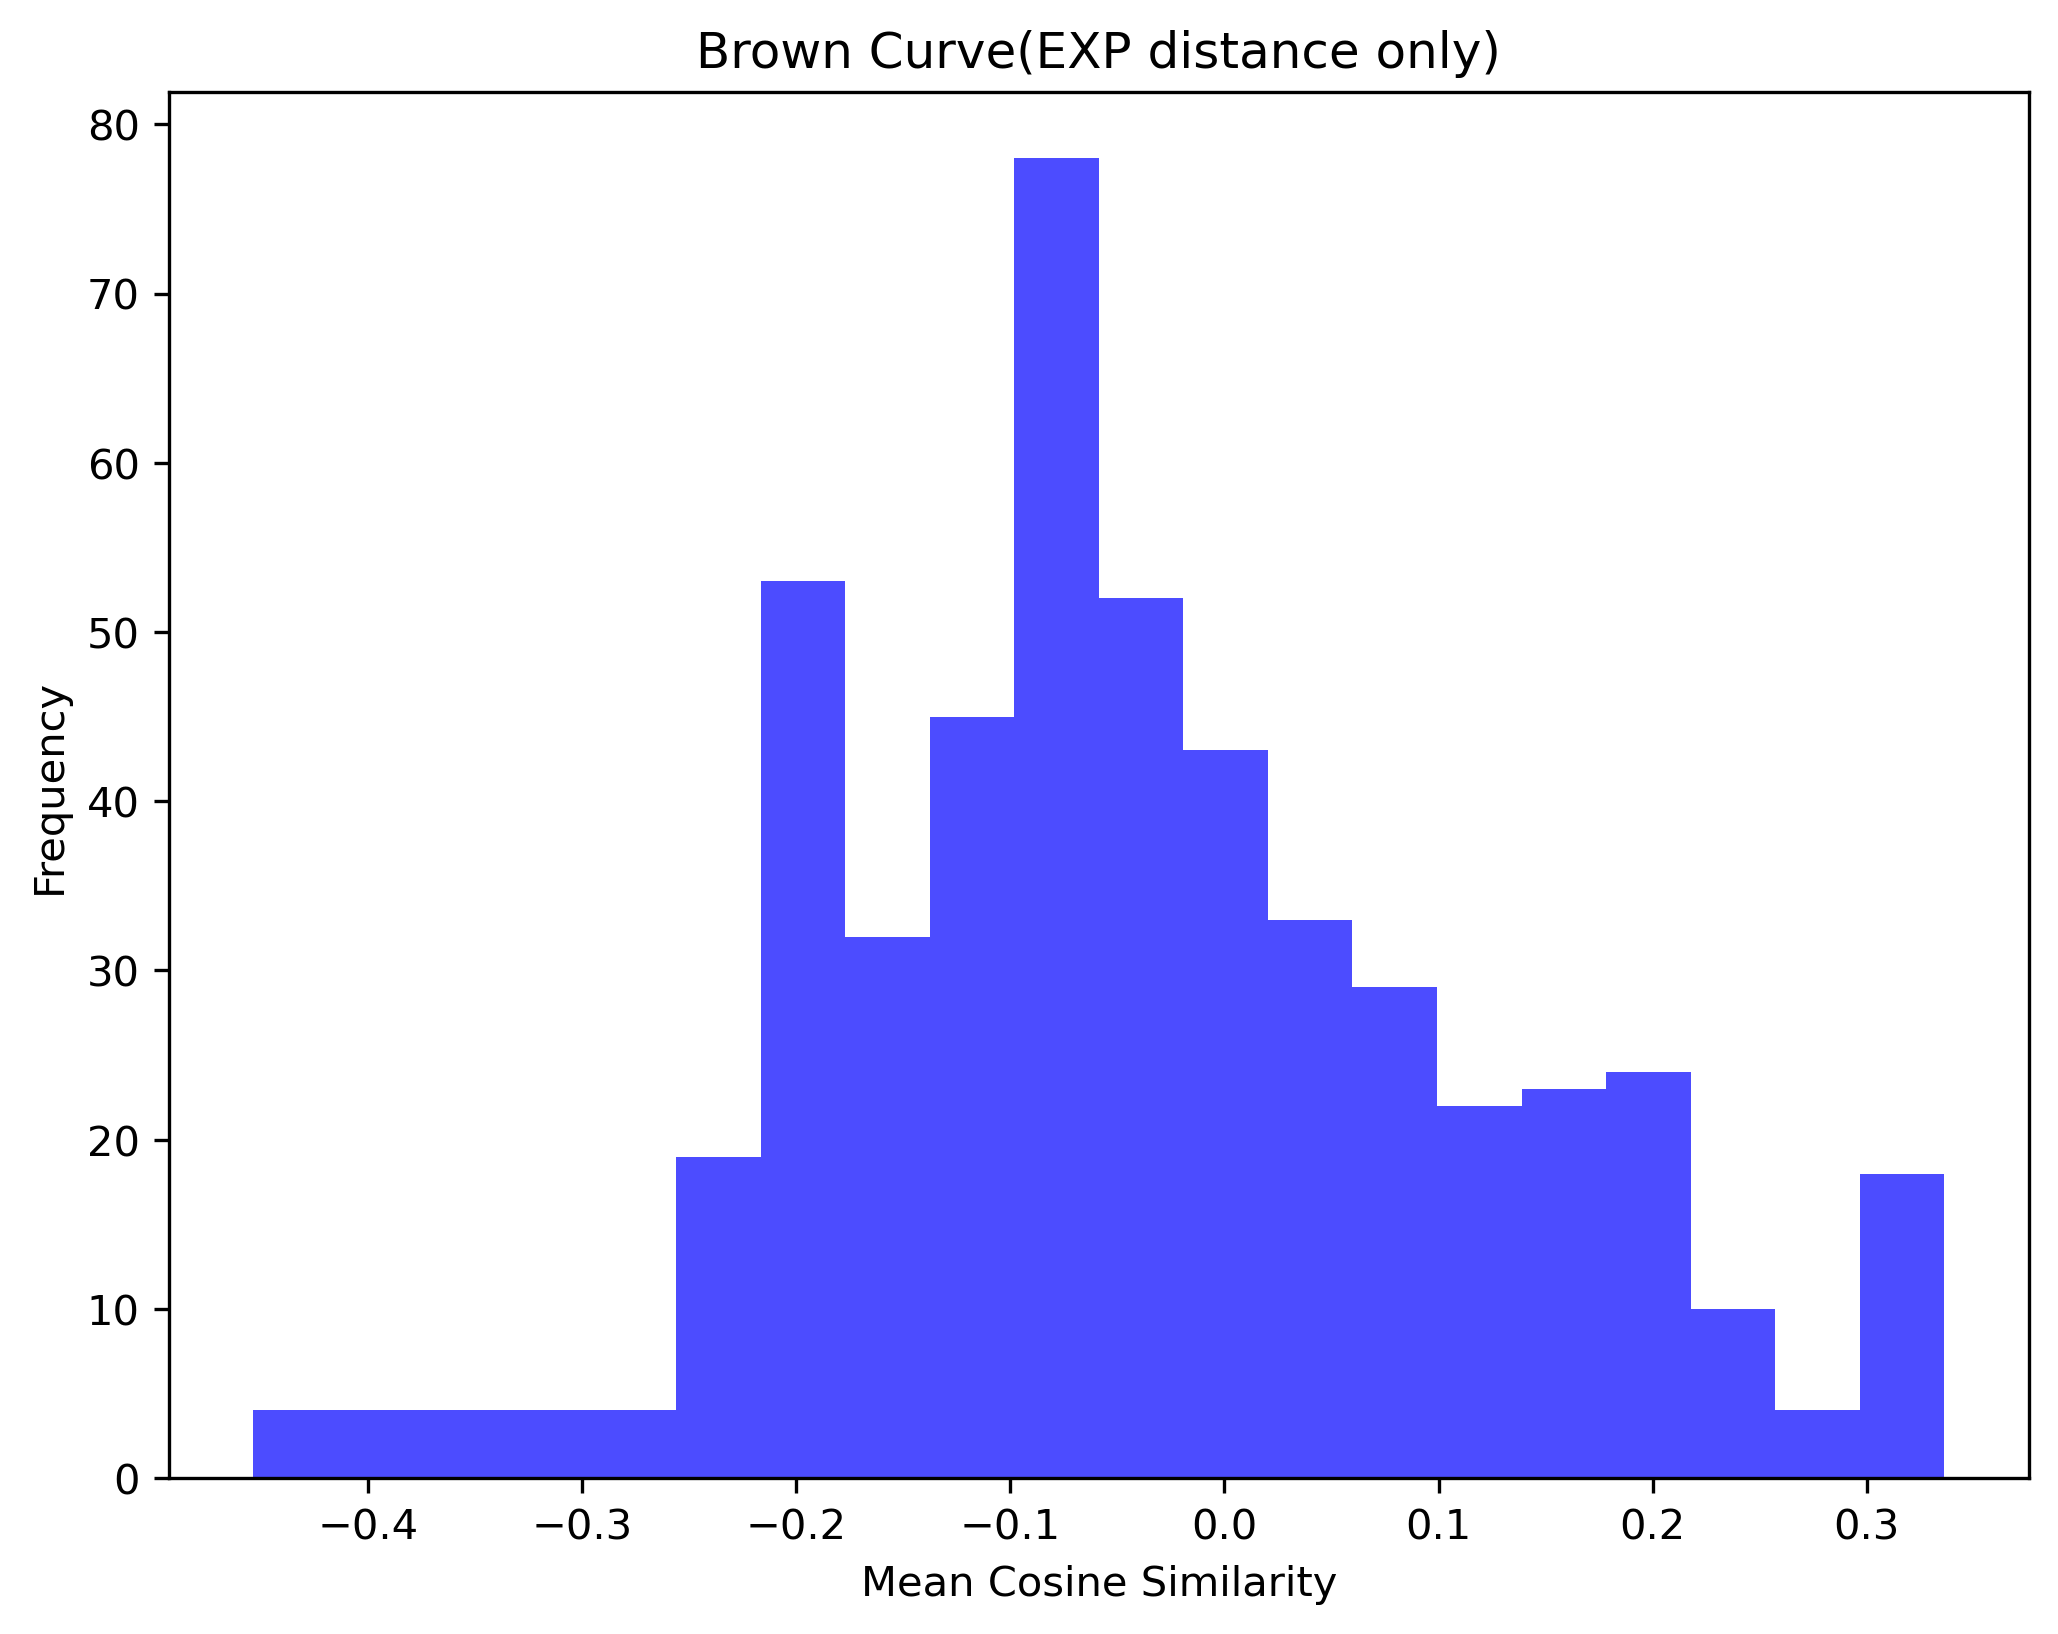

In [23]:

plt.figure(figsize=(8, 6))
plt.hist(res0[5], bins=20, color='blue', alpha=0.7)
plt.xlabel('Mean Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Brown Curve(EXP distance only)')
plt.show()

In [36]:
from scipy.stats import ttest_rel
ttest_rel(min_consines, res1[4])

TtestResult(statistic=np.float64(17.07346942173533), pvalue=np.float64(1.7936843364686723e-53), df=np.int64(594))

In [37]:
pareto_list_terminal_only_kd_internal = opt.terminal_only_rebuild_runner(use_kd_tree=True)

Computing pareto costs 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Computing pareto costs 2/2:   0%|          | 0/501 [00:00<?, ?it/s]

In [38]:
# save pareto_list_terminal_only_kd_internal as a pandas dataframe
pareto_df_terminal_only_kd_internal = pd.DataFrame(pareto_list_terminal_only_kd_internal, columns=['xyz_cost', 'exp_cost', 'internal_selection_count', 'complexity_score', 'min_consines', 'mean_consines'])
pareto_df_terminal_only_kd_internal.to_csv('output/internal_opt/embryo2/s3_280_l2/pareto_terminal_only_kd_internal.tsv', index=False, sep='\t')

In [ ]:
pareto_df_terminal_only_kd_internal = pd.read_csv('output/internal_opt/embryo2/P2/pareto_terminal_only_kd_internal.tsv', sep='\t')
pareto_xyz_cost_list_terminal_only_kd_internal = pareto_df_terminal_only_kd_internal['xyz_cost'].tolist()
pareto_exp_cost_list_terminal_only_kd_internal = pareto_df_terminal_only_kd_internal['exp_cost'].tolist()
results_df = pd.read_csv('output/internal_opt/embryo2/P2/pareto_comparison.csv')
pareto_xyz_cost_list_by_layer = results_df["Bottom-up By Layer XYZ Cost"].tolist()
pareto_exp_cost_list_by_layer = results_df["Bottom-up By Layer Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild = results_df["Top-Down Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild = results_df["Top-Down Rebuild Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) Exp Cost"].tolist()
pareto_xyz_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild Exp Cost"].tolist()    
pareto_xyz_cost_list_mst = results_df["MST Based Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_mst = results_df["MST Based Rebuild Exp Cost"].tolist()

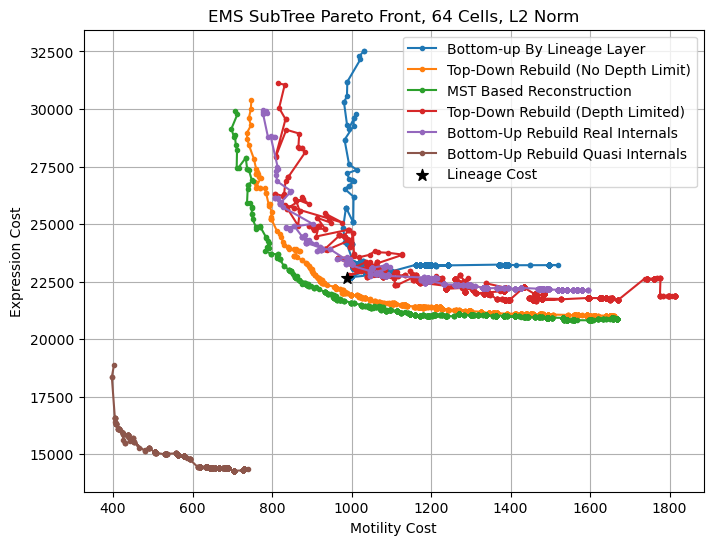

In [40]:
pareto_xyz_cost_list_by_layer = [cost[0] for cost in pareto_list_by_layer]
pareto_exp_cost_list_by_layer = [cost[1] for cost in pareto_list_by_layer]
pareto_xyz_cost_list_top_down_rebuild = [cost[0] for cost in pareto_list_top_down_rebuild]
pareto_exp_cost_list_top_down_rebuild = [cost[1] for cost in pareto_list_top_down_rebuild]
pareto_xyz_cost_list_mst = [cost[0] for cost in pareto_mst_list]
pareto_exp_cost_list_mst = [cost[1] for cost in pareto_mst_list]
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = [cost[0] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = [cost[1] for cost in pareto_list_top_down_rebuild_depth_cutoff]
pareto_xyz_cost_list_paired_bottom_up_rebuild = [cost[0] for cost in pareto_list_paired_bottom_up_rebuild]
pareto_exp_cost_list_paired_bottom_up_rebuild = [cost[1] for cost in pareto_list_paired_bottom_up_rebuild]
pareto_xyz_cost_list_terminal_only_kd_internal = [cost[0] for cost in pareto_list_terminal_only_kd_internal]
pareto_exp_cost_list_terminal_only_kd_internal = [cost[1] for cost in pareto_list_terminal_only_kd_internal]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_by_layer, pareto_exp_cost_list_by_layer, marker='o', linestyle='-',  markersize=3, label='Bottom-up By Lineage Layer')
plt.plot(pareto_xyz_cost_list_top_down_rebuild, pareto_exp_cost_list_top_down_rebuild, marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (No Depth Limit)')
plt.plot(pareto_xyz_cost_list_mst, pareto_exp_cost_list_mst, marker='o', linestyle='-',  markersize=3, label='MST Based Reconstruction')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff, pareto_exp_cost_list_top_down_rebuild_depth_cutoff, marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Depth Limited)')
plt.plot(pareto_xyz_cost_list_paired_bottom_up_rebuild, pareto_exp_cost_list_paired_bottom_up_rebuild, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild Real Internals')
plt.plot(pareto_xyz_cost_list_terminal_only_kd_internal, pareto_exp_cost_list_terminal_only_kd_internal, marker='o', linestyle='-', markersize=3, label='Bottom-Up Rebuild Quasi Internals')
plt.xlabel('Motility Cost')
plt.ylabel('Expression Cost')
plt.scatter(opt.lineage_xyz_cost, opt.lineage_exp_cost, color='black', marker='*', label='Lineage Cost', zorder=99, s=75)
plt.title(f'EMS SubTree Pareto Front, 64 Cells, L2 Norm')
plt.grid(True)
plt.legend()
plt.show()

In [41]:
results_df = pd.DataFrame({
    'Bottom-up By Layer XYZ Cost': pareto_xyz_cost_list_by_layer,
    'Bottom-up By Layer Exp Cost': pareto_exp_cost_list_by_layer,
    'Top-Down Rebuild XYZ Cost': pareto_xyz_cost_list_top_down_rebuild,
    'Top-Down Rebuild Exp Cost': pareto_exp_cost_list_top_down_rebuild,
    'Paired Bottom-Up Rebuild XYZ Cost': pareto_xyz_cost_list_paired_bottom_up_rebuild,
    'Paired Bottom-Up Rebuild Exp Cost': pareto_exp_cost_list_paired_bottom_up_rebuild,
    'MST Based Rebuild XYZ Cost': pareto_xyz_cost_list_mst,
    'MST Based Rebuild Exp Cost': pareto_exp_cost_list_mst,
    'Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost': pareto_xyz_cost_list_top_down_rebuild_depth_cutoff,
    'Top-Down Rebuild (Hard Depth Cutoff) Exp Cost': pareto_exp_cost_list_top_down_rebuild_depth_cutoff
})
results_df.to_csv('output/internal_opt/embryo2/P2/pareto_comparison.csv', index=False)

In [32]:
results_df = pd.read_csv('output/internal_opt/s3_280_3d_l2/pareto_comparison.csv')
pareto_xyz_cost_list_by_layer = results_df["Bottom-up By Layer XYZ Cost"].tolist()
pareto_exp_cost_list_by_layer = results_df["Bottom-up By Layer Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild = results_df["Top-Down Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild = results_df["Top-Down Rebuild Exp Cost"].tolist()
pareto_xyz_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) XYZ Cost"].tolist()
pareto_exp_cost_list_top_down_rebuild_depth_cutoff = results_df["Top-Down Rebuild (Hard Depth Cutoff) Exp Cost"].tolist()
pareto_xyz_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_paired_bottom_up_rebuild = results_df["Paired Bottom-Up Rebuild Exp Cost"].tolist()    
pareto_xyz_cost_list_mst = results_df["MST Based Rebuild XYZ Cost"].tolist()
pareto_exp_cost_list_mst = results_df["MST Based Rebuild Exp Cost"].tolist()

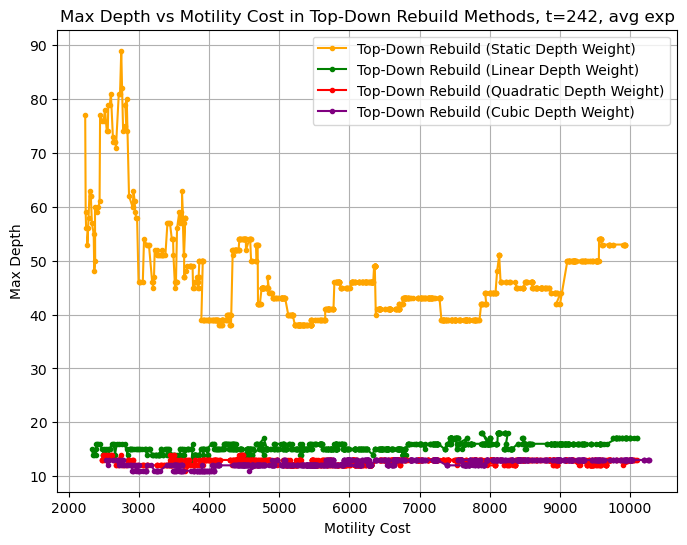

In [29]:
static_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild]
linear_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild_linear_depth_weight]
quadratic_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild_quadratic_depth_weight]
cubic_rebuild_max_depths = [cost[4] for cost in pareto_list_top_down_rebuild_cubic_depth_weight]
plt.figure(figsize=(8, 6))
plt.plot(pareto_xyz_cost_list_top_down_rebuild, static_rebuild_max_depths, color='orange', marker='o', linestyle='-',  markersize=3, label='Top-Down Rebuild (Static Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_linear_depth_weight, linear_rebuild_max_depths, color='green', marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Linear Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_quadratic_depth_weight, quadratic_rebuild_max_depths, color='red', marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Quadratic Depth Weight)')
plt.plot(pareto_xyz_cost_list_top_down_rebuild_cubic_depth_weight, cubic_rebuild_max_depths, color='purple', marker='o', linestyle='-', markersize=3, label='Top-Down Rebuild (Cubic Depth Weight)')
plt.xlabel('Motility Cost')
plt.ylabel('Max Depth')
plt.title(f'Max Depth vs Motility Cost in Top-Down Rebuild Methods, t=242, avg exp')
plt.grid(True)
plt.legend()
plt.show()

In [60]:
mst_depth = [max_depth for _, _, max_depth in pareto_mst_list]
np.mean(mst_depth), np.min(mst_depth), np.max(mst_depth)

(np.float64(37.21078921078921), np.int64(28), np.int64(58))

In [ ]:
alpha_tree_tops_list = []
for i in range(1001):
    alpha = 0 + 0.001 * i
    alpha_tree_tops_list.append((alpha, pareto_list_direct_bottom_up_rebuild[i][4]))
# plot alpha vs tree tops
alphas = [x[0] for x in alpha_tree_tops_list]
tree_tops = [x[1] for x in alpha_tree_tops_list]
plt.figure(figsize=(6,4))
plt.plot(alphas, tree_tops, marker='o', markersize=2)
plt.xlabel('Alpha (weight for XYZ cost)')
plt.ylabel('Number of tree tops after direct bottom-up rebuild')
plt.title('Alpha vs Number of Tree Tops')
plt.grid(True)

In [12]:
first_layer_names = ['ABa', 'ABp', 'P2', 'EMS']
first_layer_by_subtree = [[(3, 2)], [(4, 2)], [(5, 2)], [(6, 2)]]
for name, layer in zip(first_layer_names, first_layer_by_subtree):
    opt = LineageOptimization(
        lineage_xyz_mat, 
        lineage_exp_mat,
        lineage_tree,
        first_internal_layer=layer,
        lineage_names=common_lineages, 
        lineage_type_code_dict=complexity_code_dict,
        exp_norm=2)
    random_res = opt.random_rebuild_runner(iterations=1000000, depth_limit=10)
    random_xyz_costs = [cost[0] for cost in random_res]
    random_exp_costs = [cost[1] for cost in random_res]
    random_xyz_mean, random_xyz_std = np.mean(random_xyz_costs), np.std(random_xyz_costs)
    random_exp_mean, random_exp_std = np.mean(random_exp_costs), np.std(random_exp_costs)
    lineage_xyz_dist_from_rand = random_xyz_mean - opt.lineage_xyz_cost
    lineage_exp_dist_from_rand = random_exp_mean - opt.lineage_exp_cost
    pareto_list_by_layer = opt.bottom_up_by_layer_runner()
    pareto_list_top_down_rebuild = opt.top_down_rebuild_runner()
    pareto_mst_list = opt.mst_rebuild_runner()
    pareto_list_top_down_rebuild_depth_cutoff = opt.top_down_rebuild_runner(depth_weight_type=depth_cutoff_func)
    # pareto_list_paired_bottom_up_rebuild = opt.paired_bottom_up_rebuild_runner()
    pareto_list_terminal_only_kd_internal = opt.terminal_only_rebuild_runner(use_kd_tree=True)
    pareto_list_by_layer_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_list_by_layer])
    pareto_list_by_layer_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_list_by_layer])
    pareto_list_top_down_rebuild_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_list_top_down_rebuild])
    pareto_list_top_down_rebuild_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_list_top_down_rebuild])
    pareto_mst_list_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_mst_list])
    pareto_mst_list_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_mst_list])
    pareto_list_top_down_rebuild_depth_cutoff_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_list_top_down_rebuild_depth_cutoff])
    pareto_list_top_down_rebuild_depth_cutoff_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_list_top_down_rebuild_depth_cutoff])
    # pareto_list_paired_bottom_up_rebuild_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_list_paired_bottom_up_rebuild])
    # pareto_list_paired_bottom_up_rebuild_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_list_paired_bottom_up_rebuild])
    pareto_list_terminal_only_kd_internal_xyz_best_from_rand = random_xyz_mean - min([cost[0] for cost in pareto_list_terminal_only_kd_internal])
    pareto_list_terminal_only_kd_internal_exp_best_from_rand = random_exp_mean - min([cost[1] for cost in pareto_list_terminal_only_kd_internal])
    print(f"First layer: {name}")
    print(f"Lineage XYZ dist from random compared to bottom up by layer rebuild: {lineage_xyz_dist_from_rand/pareto_list_by_layer_xyz_best_from_rand},")
    print(f"Lineage EXP dist from random compared to bottom up by layer rebuild: {lineage_exp_dist_from_rand/pareto_list_by_layer_exp_best_from_rand},")
    print(f"Lineage XYZ dist from random compared to top down rebuild: {lineage_xyz_dist_from_rand/pareto_list_top_down_rebuild_xyz_best_from_rand},")
    print(f"Lineage EXP dist from random compared to top down rebuild: {lineage_exp_dist_from_rand/pareto_list_top_down_rebuild_exp_best_from_rand},")
    print(f"Lineage XYZ dist from random compared to MST rebuild: {lineage_xyz_dist_from_rand/pareto_mst_list_xyz_best_from_rand},")
    print(f"Lineage EXP dist from random compared to MST rebuild: {lineage_exp_dist_from_rand/pareto_mst_list_exp_best_from_rand},")
    print(f"Lineage XYZ dist from random compared to top down depth cutoff rebuild: {lineage_xyz_dist_from_rand/pareto_list_top_down_rebuild_depth_cutoff_xyz_best_from_rand},")
    print(f"Lineage EXP dist from random compared to top down depth cutoff rebuild: {lineage_exp_dist_from_rand/pareto_list_top_down_rebuild_depth_cutoff_exp_best_from_rand},")
    # print(f"Lineage XYZ dist from random compared to paired bottom up rebuild: {lineage_xyz_dist_from_rand/pareto_list_paired_bottom_up_rebuild_xyz_best_from_rand},")
    # print(f"Lineage EXP dist from random compared to paired bottom up rebuild: {lineage_exp_dist_from_rand/pareto_list_paired_bottom_up_rebuild_exp_best_from_rand},")
    print(f"Lineage XYZ dist from random compared to terminal only rebuild: {lineage_xyz_dist_from_rand/pareto_list_terminal_only_kd_internal_xyz_best_from_rand},")
    print(f"Lineage EXP dist from random compared to terminal only rebuild: {lineage_exp_dist_from_rand/pareto_list_terminal_only_kd_internal_exp_best_from_rand},")
    print("-----")


2033.475582045074 51479.28148302795 438
Parent not found for node: 0
0.1735159817351598


Computing random rebuild costs...:   0%|          | 0/1000000 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing mst test:   0%|          | 0/1001 [00:00<?, ?it/s]

...

Computing mst test:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs:   0%|          | 0/1001 [00:00<?, ?it/s]

Computing pareto costs 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Computing pareto costs 2/2:   0%|          | 0/501 [00:00<?, ?it/s]

First layer: EMS
Lineage XYZ dist from random compared to bottom up by layer rebuild: 0.8572005300708876,
Lineage EXP dist from random compared to bottom up by layer rebuild: 0.9366219656951886,
Lineage XYZ dist from random compared to top down rebuild: 0.7532348771750882,
Lineage EXP dist from random compared to top down rebuild: 0.7717367405881714,
Lineage XYZ dist from random compared to MST rebuild: 0.7436175262946618,
Lineage EXP dist from random compared to MST rebuild: 0.7403736135792977,
Lineage XYZ dist from random compared to top down depth cutoff rebuild: 0.7832934662971196,
Lineage EXP dist from random compared to top down depth cutoff rebuild: 0.8360235880615687,
Lineage XYZ dist from random compared to terminal only rebuild: 0.6627793865640399,
Lineage EXP dist from random compared to terminal only rebuild: 0.5494301052071817,
-----


In [55]:
random_res = opt.random_rebuild_runner(iterations=1000000, depth_limit=10)
random_xyz_costs = [cost[0] for cost in random_res]
random_exp_costs = [cost[1] for cost in random_res]
random_xyz_mean, random_xyz_std = np.mean(random_xyz_costs), np.std(random_xyz_costs)
random_exp_mean, random_exp_std = np.mean(random_exp_costs), np.std(random_exp_costs)
lineage_xyz_dist_from_rand = random_xyz_mean - opt.lineage_xyz_cost
lineage_exp_dist_from_rand = random_exp_mean - opt.lineage_exp_cost

pareto_list_by_layer_xyz_best_from_rand = random_xyz_mean - min(pareto_xyz_cost_list_by_layer)
pareto_list_by_layer_exp_best_from_rand = random_exp_mean - min(pareto_exp_cost_list_by_layer)
pareto_list_top_down_rebuild_xyz_best_from_rand = random_xyz_mean - min(pareto_xyz_cost_list_top_down_rebuild)
pareto_list_top_down_rebuild_exp_best_from_rand = random_exp_mean - min(pareto_exp_cost_list_top_down_rebuild)
pareto_mst_list_xyz_best_from_rand = random_xyz_mean - min(pareto_xyz_cost_list_mst)
pareto_mst_list_exp_best_from_rand = random_exp_mean - min(pareto_exp_cost_list_mst)
pareto_list_top_down_rebuild_depth_cutoff_xyz_best_from_rand = random_xyz_mean - min(pareto_xyz_cost_list_top_down_rebuild_depth_cutoff)
pareto_list_top_down_rebuild_depth_cutoff_exp_best_from_rand = random_exp_mean - min(pareto_exp_cost_list_top_down_rebuild_depth_cutoff)
pareto_list_terminal_only_kd_internal_xyz_best_from_rand = random_xyz_mean - min(pareto_xyz_cost_list_terminal_only_kd_internal)
pareto_list_terminal_only_kd_internal_exp_best_from_rand = random_exp_mean - min(pareto_exp_cost_list_terminal_only_kd_internal)
print(f"First layer: Full Tree")
print(f"Lineage XYZ dist from random compared to bottom up by layer rebuild: {lineage_xyz_dist_from_rand/pareto_list_by_layer_xyz_best_from_rand},")
print(f"Lineage EXP dist from random compared to bottom up by layer rebuild: {lineage_exp_dist_from_rand/pareto_list_by_layer_exp_best_from_rand},")
print(f"Lineage XYZ dist from random compared to top down rebuild: {lineage_xyz_dist_from_rand/pareto_list_top_down_rebuild_xyz_best_from_rand},")
print(f"Lineage EXP dist from random compared to top down rebuild: {lineage_exp_dist_from_rand/pareto_list_top_down_rebuild_exp_best_from_rand},")
print(f"Lineage XYZ dist from random compared to MST rebuild: {lineage_xyz_dist_from_rand/pareto_mst_list_xyz_best_from_rand},")
print(f"Lineage EXP dist from random compared to MST rebuild: {lineage_exp_dist_from_rand/pareto_mst_list_exp_best_from_rand},")
print(f"Lineage XYZ dist from random compared to top down depth cutoff rebuild: {lineage_xyz_dist_from_rand/pareto_list_top_down_rebuild_depth_cutoff_xyz_best_from_rand},")
print(f"Lineage EXP dist from random compared to top down depth cutoff rebuild: {lineage_exp_dist_from_rand/pareto_list_top_down_rebuild_depth_cutoff_exp_best_from_rand},")
# print(f"Lineage XYZ dist from random compared to paired bottom up rebuild: {lineage_xyz_dist_from_rand/pareto_list_paired_bottom_up_rebuild_xyz_best_from_rand},")
# print(f"Lineage EXP dist from random compared to paired bottom up rebuild: {lineage_exp_dist_from_rand/pareto_list_paired_bottom_up_rebuild_exp_best_from_rand},")
print(f"Lineage XYZ dist from random compared to terminal only rebuild: {lineage_xyz_dist_from_rand/pareto_list_terminal_only_kd_internal_xyz_best_from_rand},")
print(f"Lineage EXP dist from random compared to terminal only rebuild: {lineage_exp_dist_from_rand/pareto_list_terminal_only_kd_internal_exp_best_from_rand},")
print("-----")

Computing random rebuild costs...:   0%|          | 0/1000000 [00:00<?, ?it/s]

First layer: Full Tree
Lineage XYZ dist from random compared to bottom up by layer rebuild: 0.917326839255735,
Lineage EXP dist from random compared to bottom up by layer rebuild: 0.944341832487922,
Lineage XYZ dist from random compared to top down rebuild: 0.822911120713983,
Lineage EXP dist from random compared to top down rebuild: 0.822982511430701,
Lineage XYZ dist from random compared to MST rebuild: 0.8206108526557775,
Lineage EXP dist from random compared to MST rebuild: 0.8062662384845425,
Lineage XYZ dist from random compared to top down depth cutoff rebuild: 0.8449135118467042,
Lineage EXP dist from random compared to top down depth cutoff rebuild: 0.8849278035598064,
Lineage XYZ dist from random compared to terminal only rebuild: 0.7958792594172159,
Lineage EXP dist from random compared to terminal only rebuild: 0.624579016220562,
-----


| Subtree | Metric | Bottom Up by Layer | Top Down | MST | Top Down w/ Depth Cutoff | Terminal Only |
|---|---|---|---|---|---|---|
| **ABa** | Lineage XYZ | 0.9229 | 0.8219 | 0.8150 | 0.8657 | 0.7610 |
| **ABa** | Lineage EXP | 0.9441 | 0.8405 | 0.8226 | 0.9110 | 0.6329 |
| **ABp** | Lineage XYZ | 0.9638 | 0.8978 | 0.8879 | 0.9171 | 0.8094 |
| **ABp** | Lineage EXP | 0.8810 | 0.7490 | 0.7227 | 0.8330 | 0.5586 |
| **P2** | Lineage XYZ | 0.9935 | 0.8476 | 0.8281 | 0.8852 | 0.7026 |
| **P2** | Lineage EXP | 1.0010 | 0.9024 | 0.8917 | 0.9388 | 0.6457 |
| **EMS** | Lineage XYZ | 0.8572 | 0.7532 | 0.7436 | 0.7833 | 0.6628 |
| **EMS** | Lineage EXP | 0.9366 | 0.7717 | 0.7404 | 0.8360 | 0.5494 |
| **Full Tree** | Lineage XYZ | 0.9173 | 0.8229 | 0.8206 | 0.8449 | 0.7959 |
| **Full Tree** | Lineage EXP | 0.9443 | 0.8230 | 0.8063 | 0.8849 | 0.6246 |